<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L4_Video_Understanding_with_CNNs_and_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=mHiCDj4hUsU) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P04.pdf)

In [1]:
# Week 7, Lecture 4: Video understanding using CNN's and RNN's
from IPython.display import HTML, display

VIDEO_ID = "mHiCDj4hUsU"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 4: Video Understanding using CNNs and RNNs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.4 Video Understanding**.

**What you will learn**

- Why a single frame is often not enough, and that motion is what carries the information.
- The organising split: **time as another dimension** (3D convolution) versus **time as a separate entity** (2D convolution plus a sequence model).
- 3D convolution, and the exact layer arithmetic of the Ji et al. (2012) architecture.
- The **two-stream** network: a spatial stream on frames, a temporal stream on optical flow, combined by class-score fusion.
- **LRCN**: a CNN per frame feeding a stacked LSTM, with predictions at every timestep.

**Contents**

1. Why video needs more than a frame
2. The taxonomy: two ways to handle time
3. 3D convolution
4. The two-stream network
5. CNN + LSTM (LRCN)
6. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). No dataset is downloaded; all tensors are synthetic. Run the setup cell first, then go top to bottom.

## Review

The previous lecture built LSTMs and GRUs, whose gated additive state finally lets a
recurrent model hold information across a long gap. This lecture puts that to work on
video, alongside a purely convolutional alternative.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Why video needs more than a frame

Some events are unreadable from a still. A wingnut tumbling in microgravity flips
periodically; a single frame tells you nothing about the flip. What carries the information
is the **displacement of points over time** — that is, motion.

That observation is what splits the field in two: you can either let a convolution span
time directly, or compute motion separately and feed it to a sequence model.

In [3]:
# A single frame cannot distinguish two clips that differ only in direction of motion.
T, S = 8, 16
def moving_dot(direction):
    v = torch.zeros(T, S, S)
    for t in range(T):
        pos = t if direction > 0 else (T - 1 - t)
        v[t, S // 2, pos * 2] = 1.0
    return v

forward_clip, backward_clip = moving_dot(+1), moving_dot(-1)

same_frames = sorted(forward_clip.reshape(T, -1).sum(1).tolist()) == \
              sorted(backward_clip.reshape(T, -1).sum(1).tolist())
identical_sets = torch.allclose(forward_clip.sum(0), backward_clip.sum(0))

print(f'the two clips contain the same set of frames : {same_frames}')
print(f'summing over time gives the same image       : {identical_sets}')
print(f'but the clips are different                  : {not torch.equal(forward_clip, backward_clip)}')
print('\nany model that ignores frame order cannot tell these apart')

the two clips contain the same set of frames : True
summing over time gives the same image       : True
but the clips are different                  : True

any model that ignores frame order cannot tell these apart


## 2. The taxonomy: two ways to handle time

```
                  Understanding Videos
                   /               \
                CNNs               RNNs
              /      \
    3D Convolution   2D Convolution
          |                |
  "Time = Another    "Time = Separate
     dimension"          entity"
```

That two-word contrast is the whole lecture. Under the first reading a video is a 5D tensor
$(N, C, T, H, W)$ and the kernel spans time like any other axis. Under the second, each
frame is processed independently as $(N \cdot T, C, H, W)$ and time is handled outside the
convolution stack — by optical flow, or by a recurrent net.

In [4]:
# The two readings, as shapes.
N, C, T_, Hh, Ww = 2, 3, 16, 112, 112
video = torch.randn(N, C, T_, Hh, Ww)
print(f'video tensor                       {tuple(video.shape)}   (N, C, T, H, W)')

# Time as another dimension: a 3D conv consumes it directly.
conv3d = nn.Conv3d(C, 8, kernel_size=(3, 3, 3))
print(f'3D conv output                     {tuple(conv3d(video).shape)}')

# Time as a separate entity: fold it into the batch, run a 2D conv per frame.
frames = video.permute(0, 2, 1, 3, 4).reshape(N * T_, C, Hh, Ww)
conv2d = nn.Conv2d(C, 8, kernel_size=3)
per_frame = conv2d(frames)
print(f'2D conv on folded frames           {tuple(frames.shape)} -> {tuple(per_frame.shape)}')
print(f'unfolded back to a sequence        {tuple(per_frame.reshape(N, T_, 8, 110, 110).shape)}')

video tensor                       (2, 3, 16, 112, 112)   (N, C, T, H, W)
3D conv output                     (2, 8, 14, 110, 110)
2D conv on folded frames           (32, 3, 112, 112) -> (32, 8, 110, 110)
unfolded back to a sequence        (2, 16, 8, 110, 110)


## 3.3D convolution

In a 2D convolution each output unit sees one frame. In a 3D convolution the kernel has a
temporal extent, so one output unit sees several contiguous frames at once — motion becomes
something the filter itself can respond to.

The Ji et al. (2012) architecture in the slides makes the shapes concrete. Starting from 7
input frames at $60 \times 40$:

| Stage | Operation | Output |
|---|---|---|
| input | — | `7@60x40` |
| H1 | hardwired | `33@60x40` |
| C2 | 7x7x3 3D convolution | `23*2@54x34` |
| S3 | 2x2 subsampling | `23*2@27x17` |
| C4 | 7x6x3 3D convolution | `13*6@21x12` |
| S5 | 3x3 subsampling | `13*6@7x4` |
| — | 7x4 convolution | feature vector |
| — | full connection | output |

In [5]:
# Verify every spatial dimension in the Ji et al. table. Valid convolution: out = in - k + 1.
def conv_out(size, k): return size - k + 1
def pool_out(size, k): return size // k

h, w = 60, 40
steps = []
h, w = conv_out(h, 7), conv_out(w, 7);  steps.append(('C2  7x7x3 conv', h, w, (54, 34)))
h, w = pool_out(h, 2), pool_out(w, 2);  steps.append(('S3  2x2 pool  ', h, w, (27, 17)))
h, w = conv_out(h, 7), conv_out(w, 6);  steps.append(('C4  7x6x3 conv', h, w, (21, 12)))
h, w = pool_out(h, 3), pool_out(w, 3);  steps.append(('S5  3x3 pool  ', h, w, (7, 4)))

for name, hh, ww, expected in steps:
    ok = (hh, ww) == expected
    print(f'  {name}: {hh:3d} x {ww:3d}   slide says {expected[0]:3d} x {expected[1]:3d}   {"ok" if ok else "MISMATCH"}')
    assert ok, f'{name} disagrees with the slide'

# The final 7x4 convolution on a 7x4 map collapses to a single feature vector.
assert conv_out(7, 7) == 1 and conv_out(4, 4) == 1
print(f'\n  final 7x4 conv on a 7x4 map -> 1 x 1, i.e. a feature vector')
print(f'  channel notation 23*2 = {23*2} maps, 13*6 = {13*6} maps')

  C2  7x7x3 conv:  54 x  34   slide says  54 x  34   ok
  S3  2x2 pool  :  27 x  17   slide says  27 x  17   ok
  C4  7x6x3 conv:  21 x  12   slide says  21 x  12   ok
  S5  3x3 pool  :   7 x   4   slide says   7 x   4   ok

  final 7x4 conv on a 7x4 map -> 1 x 1, i.e. a feature vector
  channel notation 23*2 = 46 maps, 13*6 = 78 maps


In [6]:
# 3D convolution costs a factor of k more parameters than 2D, for temporal extent k.
Cin, Cout, k = 16, 32, 3
p2d = sum(p.numel() for p in nn.Conv2d(Cin, Cout, k, bias=False).parameters())
p3d = sum(p.numel() for p in nn.Conv3d(Cin, Cout, k, bias=False).parameters())

assert p3d == k * p2d, 'the 3D/2D ratio is not the temporal extent'
print(f'  2D {k}x{k} kernel   : {p2d:6d} weights')
print(f'  3D {k}x{k}x{k} kernel : {p3d:6d} weights   ({p3d // p2d}x, the temporal extent)')

# The deck's own kernels: 7x7 vs 7x7x3.
print(f'\n  slide kernels: 7x7 = {7*7} weights vs 7x7x3 = {7*7*3} weights per (in, out) pair, '
      f'a factor of {7*7*3 // (7*7)}')

  2D 3x3 kernel   :   4608 weights
  3D 3x3x3 kernel :  13824 weights   (3x, the temporal extent)

  slide kernels: 7x7 = 49 weights vs 7x7x3 = 147 weights per (in, out) pair, a factor of 3


## 4. The two-stream network

Simonyan and Zisserman (2014) take the other branch: keep 2D convolutions, and hand the
temporal information to a second network explicitly.

- The **spatial stream** sees a single RGB frame — appearance.
- The **temporal stream** sees a stack of **optical flow** fields — motion. Flow between two
  frames decomposes into a horizontal and a vertical component, so $L$ stacked flow frames
  give $2L$ input channels.
- The two softmax outputs are combined by **class score fusion**.

The layer specifications printed in the slides are identical for both streams —
`7x7x96 stride 2` → `5x5x256 stride 2` → three `3x3x512` → `4096` → `2048` → softmax — with
exactly one difference: the spatial stream normalises after conv2 and the temporal stream
does not.

In [7]:
# Build both stream inputs and the fusion step.
L_flow = 10                                   # number of stacked flow frames

spatial_in = torch.randn(1, 3, 224, 224)                 # one RGB frame
temporal_in = torch.randn(1, 2 * L_flow, 224, 224)       # L flow fields, 2 components each

print(f'  spatial stream input : {tuple(spatial_in.shape)}   (3 channels: RGB)')
print(f'  temporal stream input: {tuple(temporal_in.shape)}  (2 x {L_flow} = {2*L_flow} channels: '
      f'horizontal + vertical flow)')

conv1_spatial = nn.Conv2d(3, 96, kernel_size=7, stride=2)
conv1_temporal = nn.Conv2d(2 * L_flow, 96, kernel_size=7, stride=2)
print(f'\n  both conv1 layers produce {tuple(conv1_spatial(spatial_in).shape)} and '
      f'{tuple(conv1_temporal(temporal_in).shape)}')
print('  same 7x7x96 stride-2 spec; only the input channel count differs')

# Class score fusion: average the two softmax outputs.
n_classes = 101
s_scores = torch.softmax(torch.randn(1, n_classes), dim=1)
t_scores = torch.softmax(torch.randn(1, n_classes), dim=1)
fused = (s_scores + t_scores) / 2
assert abs(fused.sum().item() - 1.0) < 1e-5
print(f'\n  class score fusion: {tuple(s_scores.shape)} + {tuple(t_scores.shape)} -> '
      f'{tuple(fused.shape)}, sums to {fused.sum():.4f}')

  spatial stream input : (1, 3, 224, 224)   (3 channels: RGB)
  temporal stream input: (1, 20, 224, 224)  (2 x 10 = 20 channels: horizontal + vertical flow)

  both conv1 layers produce (1, 96, 109, 109) and (1, 96, 109, 109)
  same 7x7x96 stride-2 spec; only the input channel count differs

  class score fusion: (1, 101) + (1, 101) -> (1, 101), sums to 1.0000


## 5. CNN + LSTM (LRCN)

Donahue et al. (2015) take the RNN branch of the taxonomy. Each frame goes through a
**CNN** with weights shared across time, producing a feature vector per frame; those vectors
form a sequence fed to a **stack of two LSTMs**; and a prediction is emitted at **every
timestep**, not only the last.

As a shape trace:

$$(N, T, C, H, W) \;\to\; (N\cdot T, C, H, W) \;\xrightarrow{\text{CNN}}\; (N, T, D) \;\xrightarrow{\text{LSTM}\times 2}\; (N, T, \text{classes})$$

In [8]:
# A small LRCN, end to end.
class LRCN(nn.Module):
    def __init__(self, n_classes=101, feat=64, hidden=128):
        super().__init__()
        self.cnn = nn.Sequential(                    # weights shared across all timesteps
            nn.Conv2d(3, 16, 3, stride=2), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, feat))
        self.lstm = nn.LSTM(feat, hidden, num_layers=2, batch_first=True)
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, video):                        # (N, T, C, H, W)
        N, T, C, H, W = video.shape
        flat = video.reshape(N * T, C, H, W)         # fold time into the batch
        feats = self.cnn(flat).reshape(N, T, -1)     # unfold back into a sequence
        seq, _ = self.lstm(feats)
        return self.head(seq)                        # a prediction at every timestep

model = LRCN()
clip = torch.randn(2, 12, 3, 64, 64)
out = model(clip)

print(f'  input  {tuple(clip.shape)}   (N, T, C, H, W)')
print(f'  output {tuple(out.shape)}   (N, T, classes) - one prediction per timestep')
assert out.shape == (2, 12, 101)

n_cnn = sum(p.numel() for p in model.cnn.parameters())
print(f'\n  the CNN has {n_cnn:,} parameters, shared across all {clip.shape[1]} timesteps')
print(f'  UCF101 has {out.shape[-1]} action classes')

  input  (2, 12, 3, 64, 64)   (N, T, C, H, W)
  output (2, 12, 101)   (N, T, classes) - one prediction per timestep

  the CNN has 7,200 parameters, shared across all 12 timesteps
  UCF101 has 101 action classes


## 6. Explore and verify

The claims worth checking are the shape arithmetic that all three architectures rest on:
that a 3D kernel really does see several frames at once, that folding time into the batch
is equivalent to looping over frames, and that the LRCN trace holds for any $T$.

In [9]:
# Verify the shape claims that the three architectures depend on.

# 1. Folding time into the batch == looping over frames, exactly.
conv = nn.Conv2d(3, 8, 3)
clip = torch.randn(2, 5, 3, 32, 32)
N, T_, C_, H_, W_ = clip.shape
folded = conv(clip.reshape(N * T_, C_, H_, W_)).reshape(N, T_, 8, 30, 30)
looped = torch.stack([torch.stack([conv(clip[n, t][None])[0] for t in range(T_)]) for n in range(N)])
assert torch.allclose(folded, looped, atol=1e-6), 'folding is not equivalent to looping'

# 2. A 3D kernel with temporal extent k reduces T by k-1 (valid convolution).
for k in (1, 3, 5):
    c3 = nn.Conv3d(3, 4, kernel_size=(k, 3, 3))
    out_T = c3(torch.randn(1, 3, 16, 32, 32)).shape[2]
    assert out_T == 16 - k + 1, f'temporal extent {k} gave T={out_T}'
    print(f'  3D kernel with temporal extent {k}: T 16 -> {out_T}')

# 3. A temporal extent of 1 is exactly a 2D convolution applied per frame.
c3_flat = nn.Conv3d(3, 4, kernel_size=(1, 3, 3), bias=False)
c2 = nn.Conv2d(3, 4, kernel_size=3, bias=False)
with torch.no_grad():
    c2.weight.copy_(c3_flat.weight[:, :, 0])
v = torch.randn(1, 3, 6, 32, 32)
a = c3_flat(v)[0].permute(1, 0, 2, 3)
b = c2(v[0].permute(1, 0, 2, 3))
assert torch.allclose(a, b, atol=1e-5), 'temporal extent 1 is not the same as 2D'
print(f'\n  temporal extent 1 == per-frame 2D convolution: max |diff| = {(a - b).abs().max():.2e}')
print('  so "time as another dimension" collapses to "time ignored" when the extent is 1')

  3D kernel with temporal extent 1: T 16 -> 16
  3D kernel with temporal extent 3: T 16 -> 14
  3D kernel with temporal extent 5: T 16 -> 12

  temporal extent 1 == per-frame 2D convolution: max |diff| = 0.00e+00
  so "time as another dimension" collapses to "time ignored" when the extent is 1


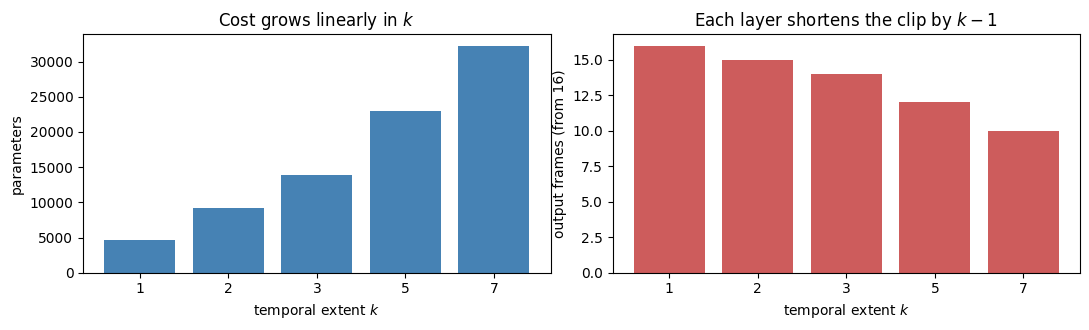

In [10]:
# Static sweep: how temporal extent trades receptive field against cost.
extents = [1, 2, 3, 5, 7]
params, out_T = [], []
for k in extents:
    c = nn.Conv3d(16, 32, kernel_size=(k, 3, 3), bias=False)
    params.append(sum(p.numel() for p in c.parameters()))
    out_T.append(c(torch.randn(1, 16, 16, 8, 8)).shape[2])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar([str(k) for k in extents], params, color='steelblue')
ax[0].set_xlabel('temporal extent $k$'); ax[0].set_ylabel('parameters')
ax[0].set_title('Cost grows linearly in $k$')
ax[1].bar([str(k) for k in extents], out_T, color='indianred')
ax[1].set_xlabel('temporal extent $k$'); ax[1].set_ylabel('output frames (from 16)')
ax[1].set_title('Each layer shortens the clip by $k-1$')
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [11]:
# Live: the LRCN shape trace for any clip length and depth.
from ipywidgets import interact, IntSlider

def trace(T_clip=12, n_classes=101, hidden=128):
    m = LRCN(n_classes=n_classes, hidden=hidden)
    v = torch.randn(1, T_clip, 3, 64, 64)
    with torch.no_grad():
        N, T_, C_, H_, W_ = v.shape
        flat = v.reshape(N * T_, C_, H_, W_)
        feats = m.cnn(flat).reshape(N, T_, -1)
        seq, _ = m.lstm(feats)
        out = m.head(seq)
    total = sum(p.numel() for p in m.parameters())
    print(f'  video   {tuple(v.shape)}')
    print(f'  folded  {tuple(flat.shape)}')
    print(f'  CNN out {tuple(feats.shape)}')
    print(f'  LSTM out{tuple(seq.shape)}')
    print(f'  logits  {tuple(out.shape)}')
    print(f'\n  {total:,} parameters, independent of T = {T_clip}')

interact(trace, T_clip=IntSlider(min=2, max=32, step=2, value=12),
                n_classes=IntSlider(min=10, max=400, step=10, value=101),
                hidden=IntSlider(min=32, max=256, step=32, value=128));

interactive(children=(IntSlider(value=12, description='T_clip', max=32, min=2, step=2), IntSlider(value=101, d…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Why video** | Motion carries information a single frame cannot; reversed clips share every frame yet differ |
| **The taxonomy** | Time as **another dimension** (3D conv) versus time as a **separate entity** (2D conv + flow or RNN) |
| **3D convolution** | The kernel spans several contiguous frames, so one unit sees motion; cost grows linearly in temporal extent |
| **Ji et al. (2012)** | 7@60x40 → 33 hardwired maps → 7x7x3 conv → subsample → 7x6x3 conv → subsample → 7x4 conv → full connection |
| **Two-stream** | Spatial stream on 3 RGB channels, temporal stream on $2L$ flow channels, combined by class score fusion |
| **LRCN** | CNN per frame with shared weights, feeding two stacked LSTMs, predicting at every timestep |
| **Datasets** | UCF101 (101 action classes); Charades / Hollywood in Homes for multi-label actions and sentence prediction |

## Exercises

1. **The homework from the slides.** What do you think happens if you train a model on normal videos and run inference on a **reversed** video? Answer separately for a two-stream network and for an LRCN, and say which is more affected and why.
2. **The hardwired layer.** Ji et al. expand 7 input frames into 33 feature maps with a fixed, non-learned layer. Work out a decomposition of 33 that fits 7 frames, and say what each group would compute. (Hint: the components include gradients and optical flow, and flow between 7 frames gives 6 fields.)
3. **How many flow channels?** The temporal stream takes $L$ stacked flow frames. Write out the conv1 input channel count for $L = 1, 5, 10, 20$, and say what limits how large $L$ can be.
4. **Where does the clip run out?** A 3D network with temporal extent 3 at every layer shortens the clip by 2 per layer. How many such layers can a 16-frame clip support before the temporal dimension vanishes, and what would you change to go deeper?
5. **Fusion, done differently.** Section 4 averaged the two softmax outputs. Implement a learned fusion instead — concatenate the two feature vectors and train a linear layer — and say what it can represent that averaging cannot.
